# Amazon Sales Data Analysis (EDA)

IMPORT ALL NECESSARY LIBRARIES

In [339]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the amazon dataset

In [340]:
df=pd.read_csv('data/amazon_product.csv')


Display the data set

In [341]:
df.head()
# df.tail(5)

,Unnamed: 0,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,...,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,sales_volume,delivery,has_variations,product_availability,unit_price,unit_count
0,0,B0BQ118F2T,Moto G Play 2023 3-Day Battery Unlocked Made f...,$99.99,$169.99,USD,4.0,2929,https://www.amazon.com/dp/B0BQ118F2T,https://m.media-amazon.com/images/I/61K1Fz5Lxv...,...,False,False,True,False,6K+ bought in past month,"FREE delivery Tue, Aug 6",True,NaN,NaN,NaN
1,1,B0CTD47P22,"SAMSUNG Galaxy A15 5G (SM-156M/DSN), 128GB 6GB...",$149.74,$158.00,USD,4.2,135,https://www.amazon.com/dp/B0CTD47P22,https://m.media-amazon.com/images/I/51QhB2CfqS...,...,False,False,True,False,3K+ bought in past month,"FREE delivery Wed, Aug 7 Only 7 left in stock ...",False,Only 7 left in stock - order soon.,NaN,NaN
2,2,B0CHH6X6H2,Total by Verizon | Samsung Galaxy A03s | Locke...,$49.88,NaN,USD,3.9,205,https://www.amazon.com/dp/B0CHH6X6H2,https://m.media-amazon.com/images/I/812woqv69C...,...,False,False,True,False,2K+ bought in past month,"FREE delivery Tue, Aug 6",False,NaN,NaN,NaN
3,3,B0BZ9XNBRB,Google Pixel 7a - Unlocked Android Cell Phone ...,$335.00,$499.00,USD,4.3,2248,https://www.amazon.com/dp/B0BZ9XNBRB,https://m.media-amazon.com/images/I/61r7cCpQPl...,...,False,False,False,False,10K+ bought in past month,FREE delivery Aug 6 - 8,True,NaN,NaN,NaN
4,4,B0CN1QSH8Q,"SAMSUNG Galaxy A15 5G A Series Cell Phone, 128...",$199.99,NaN,USD,4.1,423,https://www.amazon.com/dp/B0CN1QSH8Q,https://m.media-amazon.com/images/I/61s0ZzwzSC...,...,False,False,True,True,3K+ bought in past month,"FREE delivery Tue, Aug 6",True,NaN,NaN,NaN


DataSet info

In [342]:
# df.info()
df
# df.describe()
# df.shape
# df.dtypes
df.isnull().sum()
# df.duplicated().sum()
# df.drop_duplicates(inplace=True)


Unnamed: 0                      0
asin                            0
product_title                   0
product_price                   0
product_original_price         37
currency                        0
product_star_rating            10
product_num_ratings             0
product_url                     0
product_photo                   0
product_num_offers              0
product_minimum_offer_price     0
is_best_seller                  0
is_amazon_choice                0
is_prime                        0
climate_pledge_friendly         0
sales_volume                    3
delivery                        1
has_variations                  0
product_availability           63
unit_price                     59
unit_count                     59
dtype: int64

Filled the product_orignal_price with the product_price because no discount applied on that product

In [343]:
# df[df['product_original_price'].isnull()]
df['product_original_price'] = df['product_original_price'].fillna(df['product_price'])

Find product star rating and fill the empty colums with median

In [344]:
df['product_star_rating'].median()
df['product_star_rating'] = df['product_star_rating'].fillna(df['product_star_rating'].median())
# df['product_star_rating'].isnull().sum()

Null Sales Volume columns filled with unknown

In [345]:
df['sales_volume'] = df['sales_volume'].fillna('unknown')
# df['sales_volume'].isnull().sum()

Find mode and fill with mode (delivery column)

In [346]:
df['delivery'].mode()
df['delivery'] = df['delivery'].fillna(df['delivery'].mode()[0])
df['delivery'].isnull().sum()

np.int64(0)

checking the unique outcomes for product availability

In [347]:
df['product_availability'].unique()
df['product_availability'] = df['product_availability'].fillna('unknown')
df['product_availability'].isnull().sum()

np.int64(0)

unit_price 

In [348]:
df['unit_price'].sample(20)
df['unit_price']=df['unit_price'].fillna('unknown')
df['unit_price'].isnull().sum()

np.int64(0)

unit_count

In [349]:
# df['unit_count'].sample(20)
df['unit_count'] = df['unit_count'].fillna(df['unit_count'].median())
df['unit_count'].isnull().sum()

np.int64(0)

Separate Numerical and the categorical columns

In [350]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Unnamed: 0', 'product_star_rating', 'product_num_ratings',
       'product_num_offers', 'unit_count'],
      dtype='str')

Categorical Columns:
Index(['asin', 'product_title', 'product_price', 'product_original_price',
       'currency', 'product_url', 'product_photo',
       'product_minimum_offer_price', 'sales_volume', 'delivery',
       'product_availability', 'unit_price'],
      dtype='str')


# Saving the cleaned Data set

In [351]:
df.to_csv('data/cleaned_amazon_products.csv', index=False)

Product_star_rating (PLOT)

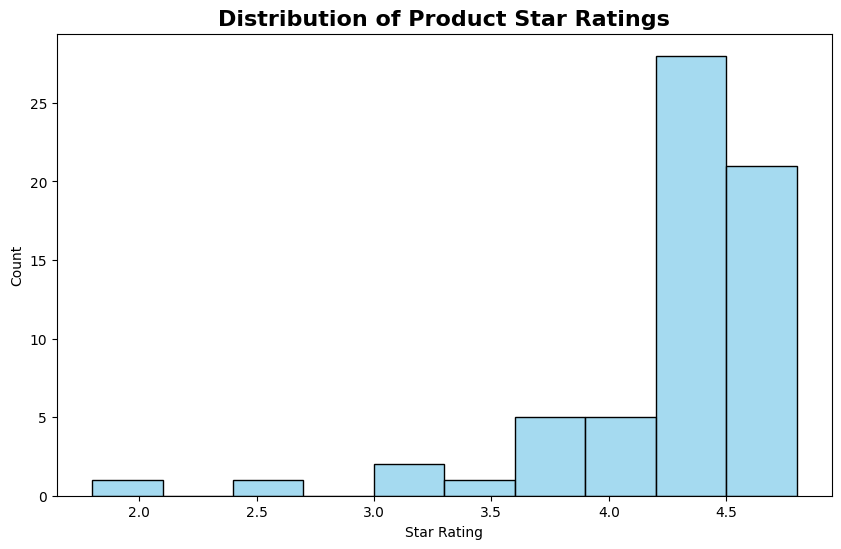

In [352]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='product_star_rating', bins=10,color='skyblue')
plt.title("Distribution of Product Star Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()

Product_num_rating (plot)

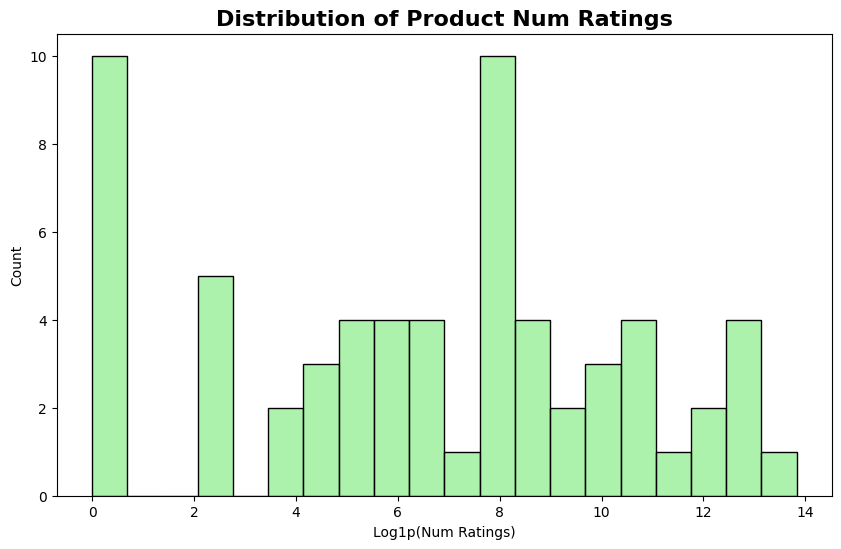

In [353]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['product_num_ratings']), bins=20, color='lightgreen')
plt.title("Distribution of Product Num Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Log1p(Num Ratings)")
plt.ylabel("Count")
plt.show()

product_num_offers (PLOT)

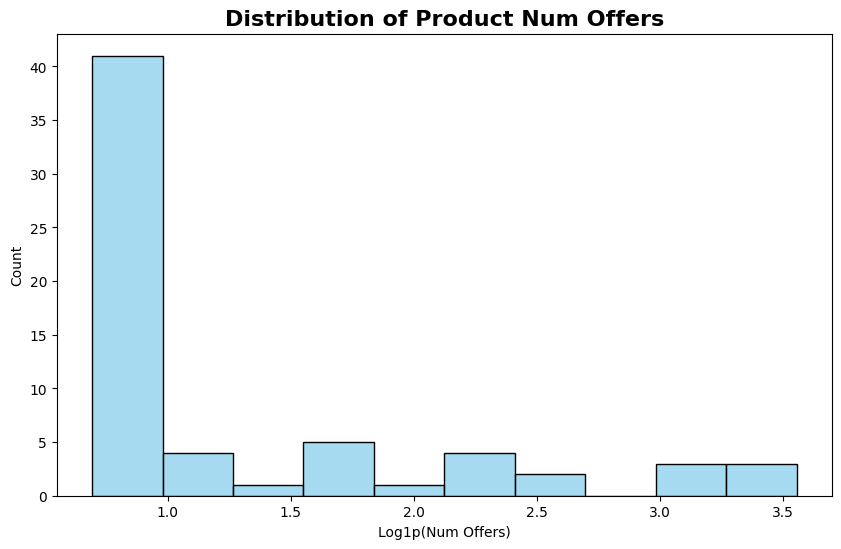

In [354]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['product_num_offers']), bins=10,color='skyblue')
plt.title("Distribution of Product Num Offers", fontsize=16, fontweight='bold')
plt.xlabel("Log1p(Num Offers)")
plt.ylabel("Count")
plt.show()

Unit_count(PLOT)

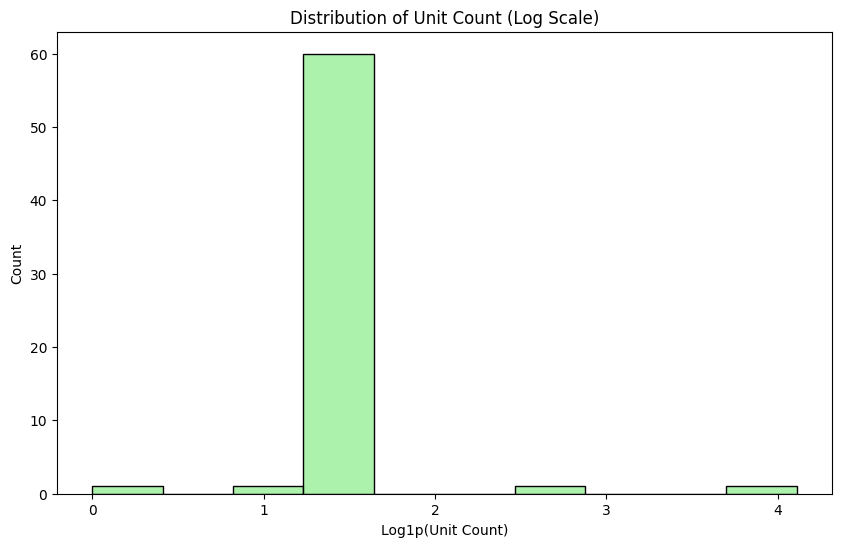

In [355]:
plt.figure(figsize=(10,6))

sns.histplot(np.log1p(df['unit_count']),
             bins=10,
             color='lightgreen')

plt.title("Distribution of Unit Count (Log Scale)")
plt.xlabel("Log1p(Unit Count)")
plt.ylabel("Count")

plt.show()

# PLOTS for the categorical Products

In [356]:
df['product_price'].head(20)
df['product_price'] = (
    df['product_price']
    .str.replace('$', '', regex=False)
    .astype(float)
)

histplot on product_price

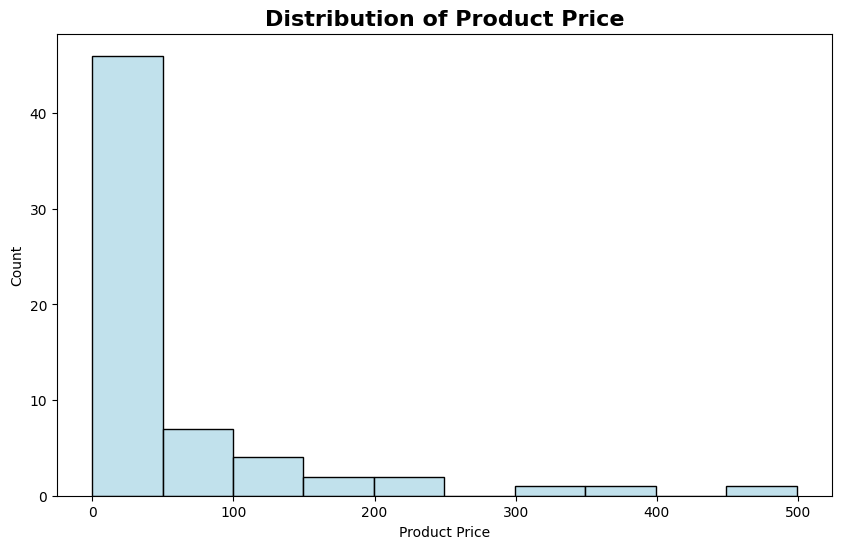

In [357]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df,x='product_price',bins=10,color='lightblue')
plt.title("Distribution of Product Price", fontsize=16, fontweight='bold')
plt.xlabel("Product Price")
plt.ylabel("Count")
plt.show()


countplot for currency

In [358]:
df = df[df['sales_volume'].str.contains('bought', case=False, na=False)]

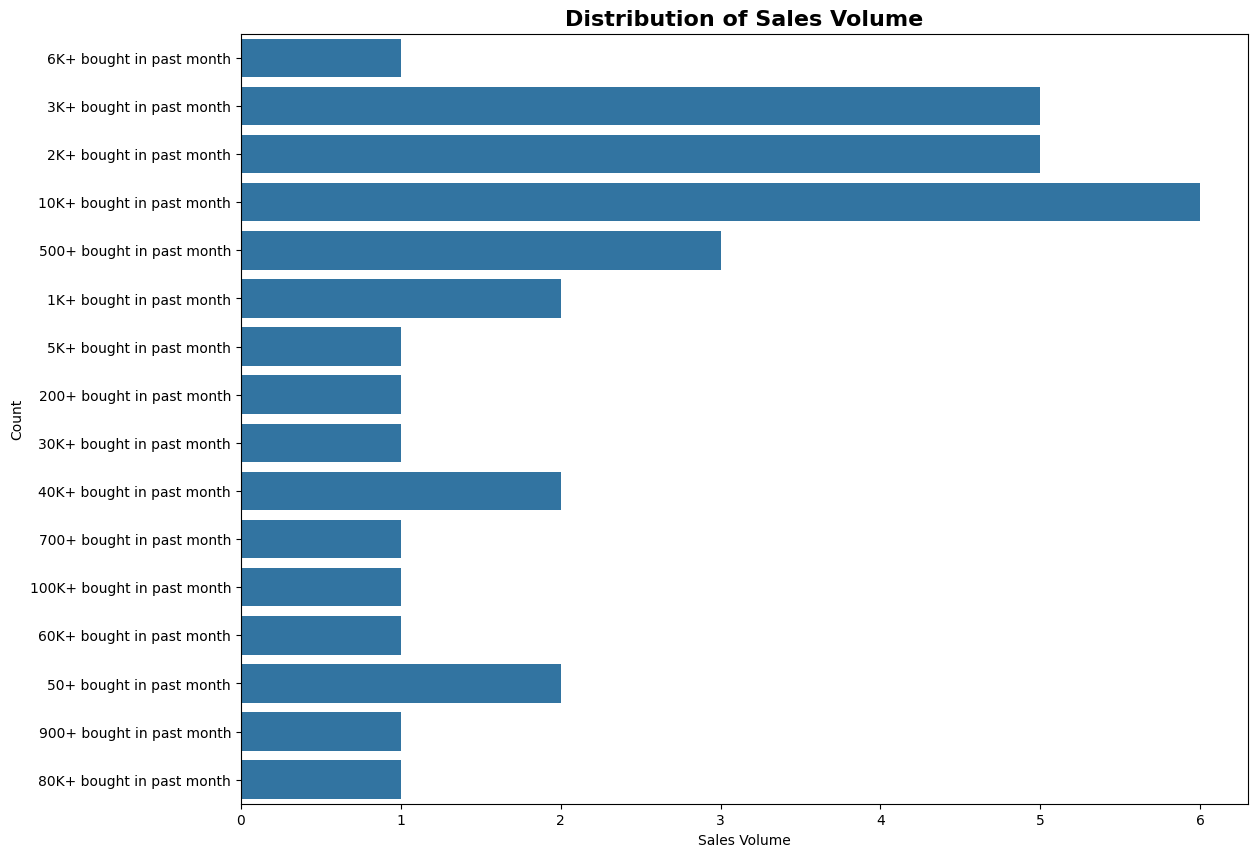

In [359]:
plt.figure(figsize=(13, 10))
sns.countplot(data=df,y='sales_volume')
plt.title("Distribution of Sales Volume", fontsize=16, fontweight='bold')
plt.xlabel("Sales Volume")
plt.ylabel("Count")
plt.show()

product_minimum_offer type conversion

In [360]:
df['product_minimum_offer_price'].head(20)
df['product_minimum_offer_price'] = (
    df['product_minimum_offer_price']
    .str.replace('$', '', regex=False)
    .astype(float))

product_minimum_offer_price plot

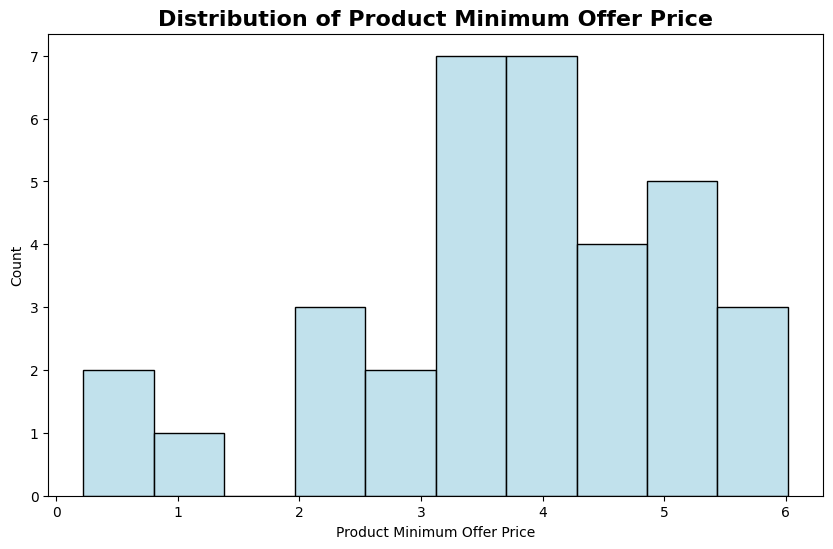

In [361]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=np.log1p(df['product_minimum_offer_price']), bins=10, color='lightblue')
plt.title("Distribution of Product Minimum Offer Price", fontsize=16, fontweight='bold')
plt.xlabel("Product Minimum Offer Price")
plt.ylabel("Count")
plt.show()


# Bivariate Analysis

( Product_price and Product_star_rating)

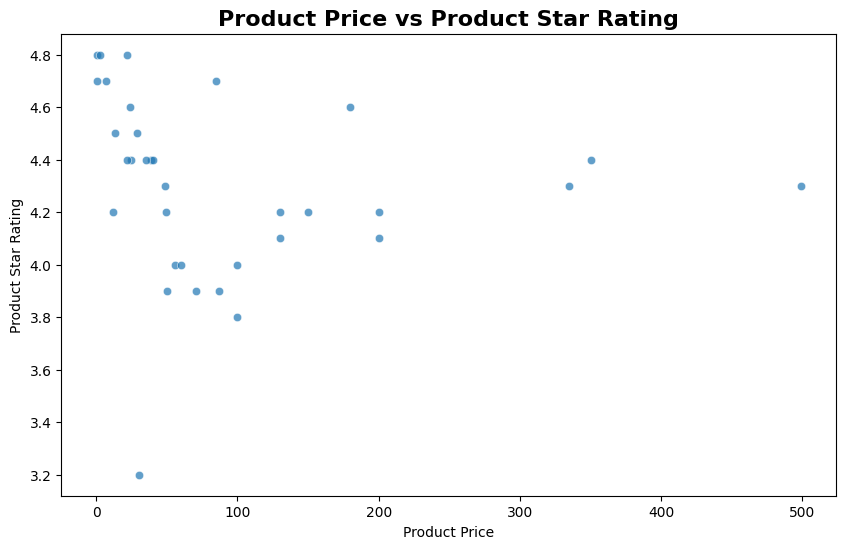

In [362]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='product_price', y='product_star_rating',alpha=0.7)
plt.title("Product Price vs Product Star Rating", fontsize=16, fontweight='bold')
plt.xlabel("Product Price")
plt.ylabel("Product Star Rating")
plt.show()

product_price vs product_num_rating

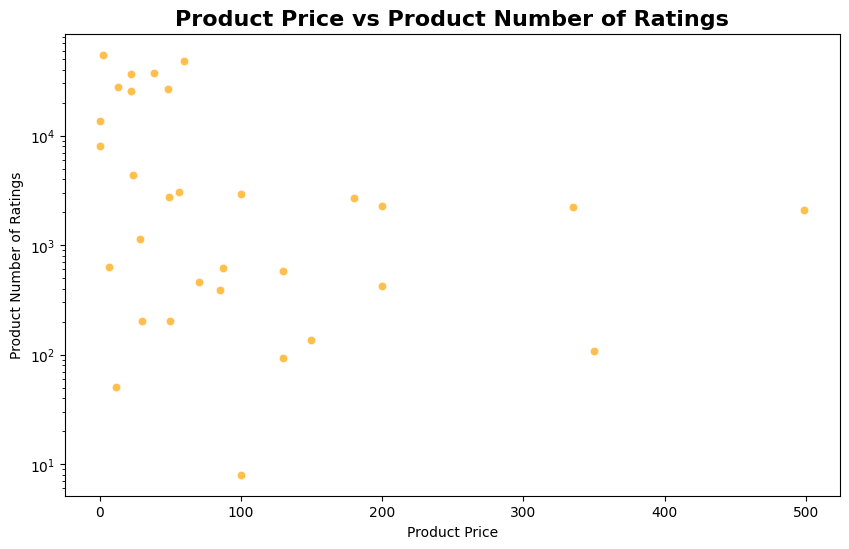

In [363]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='product_price', y='product_num_ratings',alpha=0.7,color='orange')
plt.title("Product Price vs Product Number of Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Product Price")
plt.ylabel("Product Number of Ratings")
plt.yscale('log')
plt.show()

product_price vs product_num_offer

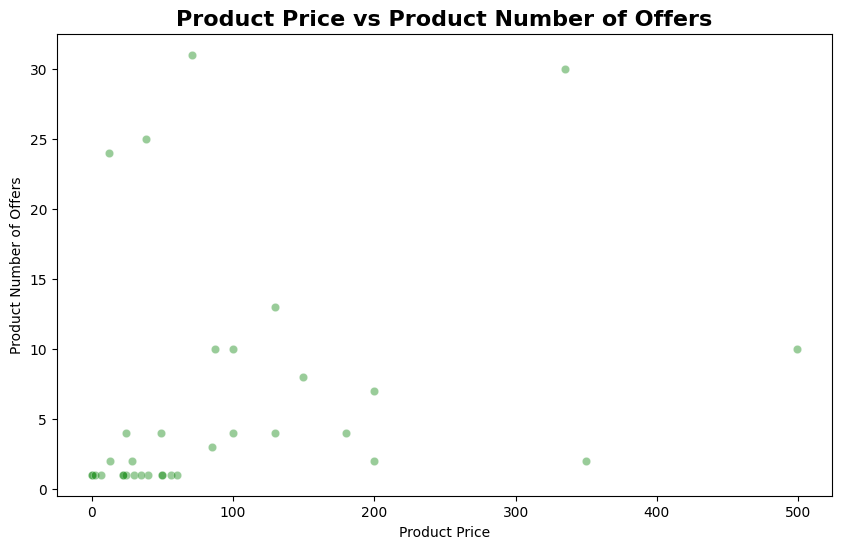

In [364]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='product_price', y='product_num_offers',alpha=0.4,color='green')
plt.title("Product Price vs Product Number of Offers", fontsize=16, fontweight='bold')
plt.xlabel("Product Price")
plt.ylabel("Product Number of Offers")
plt.show()

product_star_rating vs product_num_rating

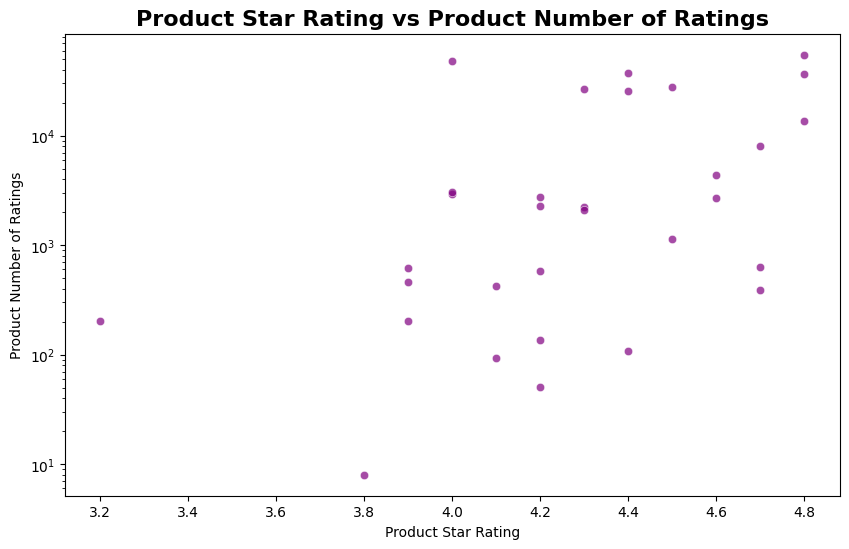

In [365]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='product_star_rating', y='product_num_ratings',alpha=0.7,color='purple')
plt.title("Product Star Rating vs Product Number of Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Product Star Rating")
plt.yscale('log')
plt.ylabel("Product Number of Ratings")
plt.show()

In [366]:
df = df[df['sales_volume'].str.contains('bought', case=False, na=False)]

product_title vs Product_price

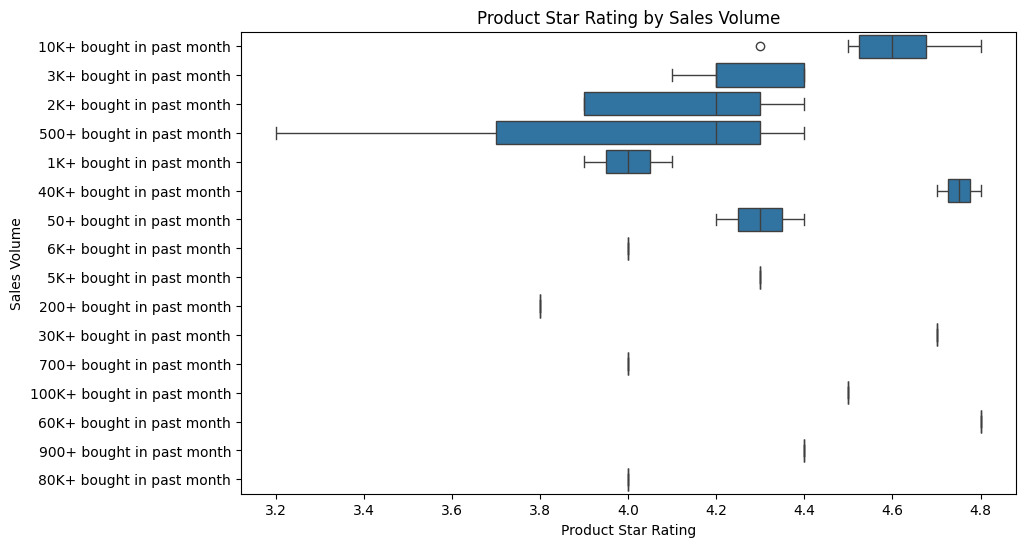

In [367]:
order = df['sales_volume'].value_counts().index

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='product_star_rating',
    y='sales_volume',
    order=order
)

plt.title("Product Star Rating by Sales Volume")
plt.xlabel("Product Star Rating")
plt.ylabel("Sales Volume")

plt.show()


Product_price vs product_orignal price

In [368]:
df['product_original_price'] = df['product_original_price'].str.replace('$', '', regex=False).astype(float)


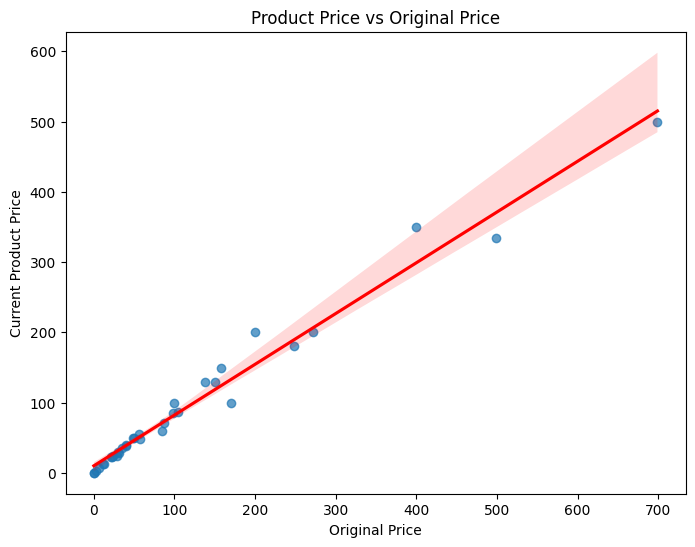

In [369]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='product_original_price',
    y='product_price',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}
)

plt.title("Product Price vs Original Price")
plt.xlabel("Original Price")
plt.ylabel("Current Product Price")

plt.show()

Coorelation Heatmap for all numerical variables

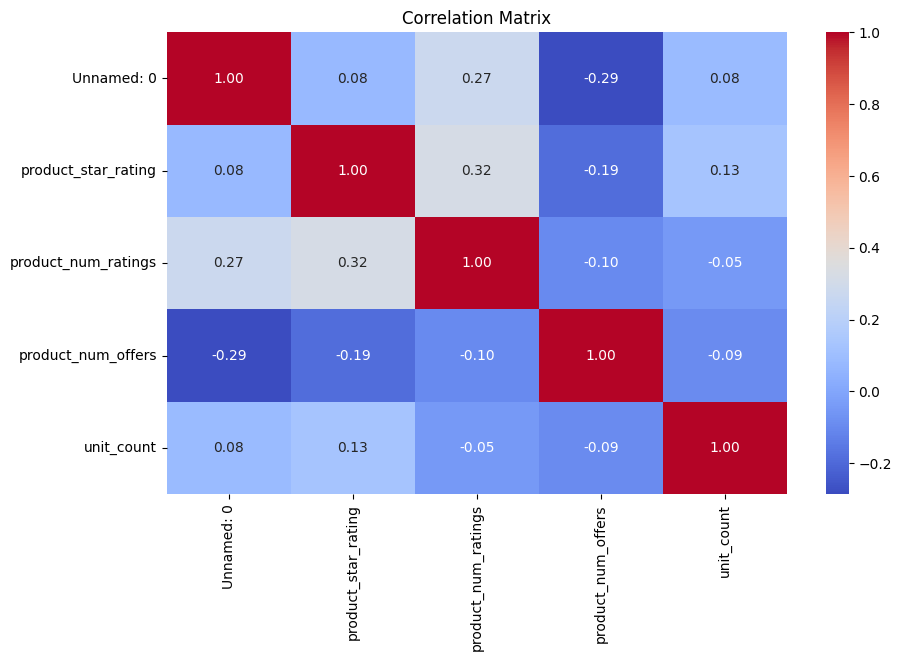

In [370]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()